In [1]:
import os, gc
import pickle
import gzip
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from data_processing_utils import * 
%config InlineBackend.figure_format = 'svg'
#mpl.rcParams['figure.dpi'] = 150  
#mpl.rcParams['savefig.dpi'] = 150
#mpl.rcParams['figure.figsize'] = (4,2)  

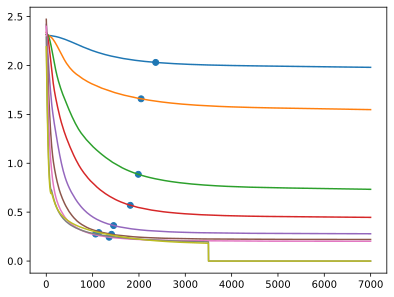

In [2]:
N_neurons_vec_PEPG = [5, 10, 20 ,30, 50, 75, 100,150,180]

with gzip.open('paramscan_PNN_PEPG_MNIST_run1.pkl.gz', 'rb') as f:
    resultsPEPG1 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run2.pkl.gz', 'rb') as f:
    resultsPEPG2 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run3.pkl.gz', 'rb') as f:
    resultsPEPG3 = pickle.load(f)

dicts_list = [resultsPEPG1, resultsPEPG2,resultsPEPG3]  # list of runs

# Average them with our new shiny function lol
avg_results_PEPG = average_data_dicts(dicts_list)

#locate convergence knee to determine convergence
knee_idx_PEPG,loss_PEPG_conv,acc_PEPG_conv = locate_curve_knee(avg_results_PEPG,N_neurons_vec_PEPG,idx_start = 150,window_len=200,plot_bool=True,method = 'default')

In [3]:
avg_results_PEPG[-4]['test_loss'][-1]

np.float64(0.22037200562783968)

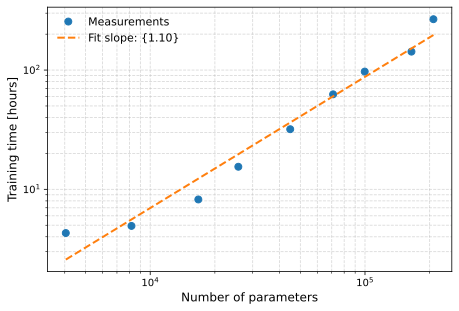

In [32]:
#change for time till convergence to extimate complexity in a roundabout way lol

n = []
t = []

for k in range(len(N_neurons_vec_PEPG)):
    n.append(avg_results_PEPG[k]["n_params"])
    t.append(avg_results_PEPG[k]["time"]/3600)

a,b = np.polyfit(np.log10(n),np.log10(t),1)

fit_dat = 10**(a*np.log10(n)+b)
C= 10**b

# Plot
plt.figure(figsize=(6.5, 4.5))
plt.loglog(n, t, 'o', markersize=7, label="Measurements")
plt.loglog(n, fit_dat, '--', linewidth=2,
           label=f"Fit slope: {{{a:.2f}}}")

plt.xlabel("Number of parameters", fontsize=12)
plt.ylabel("Training time [hours]", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
avg_results_PEPG[-1]["time"]/3600/24

np.float64(11.124302897964732)

slope 1.5025095132056443
intercept -4.20702687763201
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 208270]


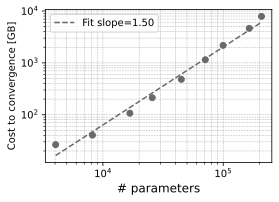

In [3]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

PEPG_mem_perepoch = np.array([11.2,19.76,53.82,117.27,330.8,816.62,1603.96,4347.31,6951.7])/1000 #with peak mem CUDA torch profiler
#PEPG_mem_perepoch = np.array([1.945, 7.866, 32.592, 76.537, 231.036, 578.829, 1141.121, 3103.629, 4967.196])/1000 #with peak mem theory

a_PEPG,b_PEPG,N_dim_vec_PEPG,PEPG_cost_to_conv = process_cost_to_conv(avg_results_PEPG,knee_idx_PEPG,PEPG_mem_perepoch)

In [5]:
knee_idx_PEPG

array([2457, 2132, 2098, 1949, 1523, 1424, 1362, 1147, 1176])

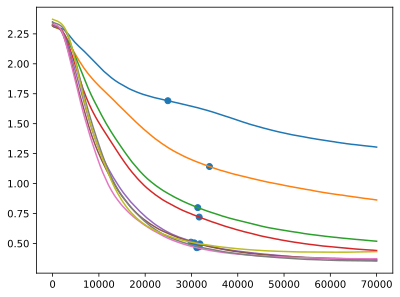

In [8]:
N_neurons_vec_SPSA = [5, 10, 20 ,30, 50, 75, 100,150,250]

with gzip.open('paramscan_PNN_SPSA_MNIST_run1.pkl.gz', 'rb') as f:
    results_SPSA1 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run2.pkl.gz', 'rb') as f:
    results_SPSA2 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run3.pkl.gz', 'rb') as f:
    results_SPSA3 = pickle.load(f)

dicts_list = [results_SPSA1, results_SPSA2,results_SPSA3]  # list of runs


# Average them with our new shiny function lol
avg_results_SPSA = average_data_dicts(dicts_list)

#locate convergence knee to determine convergence
knee_idx_SPSA,loss_SPSA_conv,acc_SPSA_conv = locate_curve_knee(avg_results_SPSA,N_neurons_vec_SPSA,idx_start = 8000,plot_bool=True,method = 'default')



slope 1.017759260960416
intercept -2.8155309482413973
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]


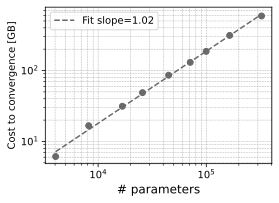

In [9]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

SPSA_mem_perepoch = np.array([0.246, 0.492, 1, 1.54,2.7,4.26,5.98,9.88,19.67])/1000 # CUDA torch Peak

a_SPSA,b_SPSA,N_dim_vec_SPSA,SPSA_cost_to_conv = process_cost_to_conv(avg_results_SPSA,knee_idx_SPSA,SPSA_mem_perepoch)



In [ ]:
#with open('75_PNN_CMA_MNIST_run1.pkl', 'rb') as f:
#    dummy2 = pickle.load(f)

In [ ]:
#with gzip.open('paramscan5to75_PNN_CMA_MNIST.pkl.gz', 'wb') as f:
#    pickle.dump(results_CMA1,f)

In [ ]:
#results_CMA1.append(dummy2[0])

In [ ]:
#len(results_CMA1)

7

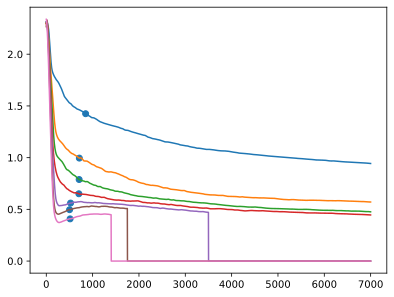

In [10]:
N_neurons_vec_CMA = [5, 10,15, 20 ,30,50,75]

with gzip.open('paramscan5to75_PNN_CMA_MNIST.pkl.gz', 'rb') as f:
    results_CMA1 = pickle.load(f)



dicts_list = [results_CMA1]  # list of runs


# Average them with our new shiny function lol
avg_results_CMA = average_data_dicts(dicts_list)

#locate convergence knee to determine convergence
knee_idx_CMA,loss_CMA_conv,acc_CMA_conv = locate_curve_knee(avg_results_CMA,N_neurons_vec_CMA,idx_start = 250,plot_bool=True,method = 'default')



In [22]:
knee_idx_CMA

array([849, 713, 709, 703, 524, 503, 514])

slope 1.9606712414266172
intercept -4.480489279337815
NUms params : [4045, 8180, 12415, 16750, 25720, 44860, 71035]


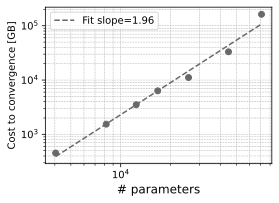

In [11]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

CMA_mem_perepoch = np.array([533.5,2162.1,4953.9,9009.4,21246,65867,316161])/1000 # CUDA torch Peak

a_CMA,b_CMA,N_dim_vec_CMA,CMA_cost_to_conv = process_cost_to_conv(avg_results_CMA,knee_idx_CMA,CMA_mem_perepoch)


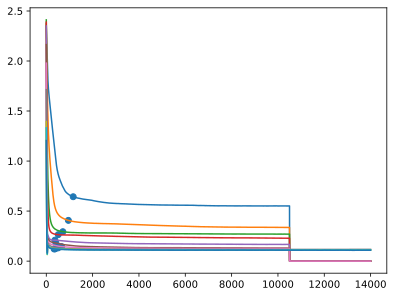

In [12]:
N_neurons_vec_BP = [5, 10, 20 ,30, 50, 75, 100,150,250,300,400]

with gzip.open('paramscan_PNN_BP_MNIST_run1.pkl.gz', 'rb') as f:
    results_BP1 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run2.pkl.gz', 'rb') as f:
    results_BP2 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run3.pkl.gz', 'rb') as f:
    results_BP3 = pickle.load(f)


#with open('BP_batch_scan/paramscan_batch10_lr0p0001_PNN_BP_MNIST.pkl', 'rb') as f:
#    results_BP_lasthope = pickle.load(f)

dicts_list = [results_BP1, results_BP2,results_BP3]  # list of runs
#dicts_list = [results_BP_lasthope]  # list of runs



# Average them with our new shiny function lol
avg_results_BP = average_data_dicts(dicts_list)


#locate convergence knee to determine convergence
knee_idx_BP,loss_BP_conv,acc_BP_conv = locate_curve_knee(avg_results_BP,N_neurons_vec_BP,idx_start = 100,idx_run=-1,plot_bool=True,method = 'default')

1009


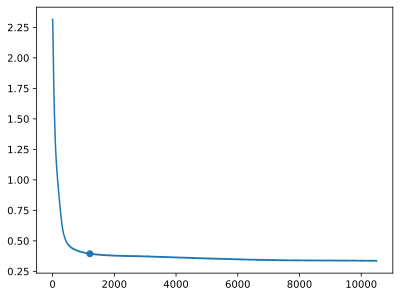

In [12]:

idx_plot = 1
smooth_loss1 = scipy.signal.savgol_filter(avg_results_BP[idx_plot]['test_loss'],window_length=100,polyorder=3)

plt.plot(avg_results_BP[idx_plot]['test_loss'])


idx_start = 200
kneedle = KneeLocator(
        np.arange(idx_start,len(smooth_loss1)), smooth_loss1[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",           
        direction="decreasing",    # loss goes down with epochs
        online=False
    )
print(kneedle.knee)
plt.scatter(kneedle.knee + idx_start,avg_results_BP[idx_plot]['test_loss'][kneedle.knee+idx_start])

In [17]:
knee_idx_BP

array([1161,  953,  715,  516,  372,  413,  660,  513,  389,  374,  338])

In [13]:
idx_plot = 5
smooth_loss1 = scipy.signal.savgol_filter(avg_results_BP[idx_plot]['test_loss'],window_length=200,polyorder=3)

slope -0.11574619892062966
intercept 1.701942989853384
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


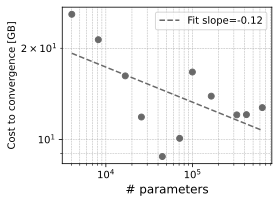

In [14]:
#process memory cost for the algorithm using the knee idx and the memory budget per epoch

BP_mem_perepoch = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000 #peak total theory batch = 1000
BP_mem_perepoch = np.array([22.3,22.4,22.68,22.99,23.62,24.43,25.3,27.1,31,32.3, 37.7])/1000 #peak total batch = 1000 torch cuda

#BP_mem_perepoch = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 10
#BP_mem_perepoch = np.array([0.019, 0.035, 0.07, 0.106, 0.182, 0.286, 0.401, 0.66, 1.299, 1.679, 2.557])/1000 #peak total batch = 10 torch cuda

#BP_mem_perepoch = np.array([18.19,18.27,18.44,18.62,19,19.52,20.1,21.4,24.59,26.49,31.05])/1000 #peak total batch = 1 torch cuda
knee_idx_BP
a_BP,b_BP,N_dim_vec_BP,BP_cost_to_conv = process_cost_to_conv(avg_results_BP,knee_idx_BP,BP_mem_perepoch)

In [16]:
avg_results_BP[0]["train_loss"].shape

(90000,)

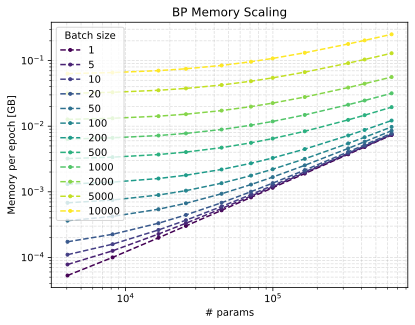

In [15]:
BP_mem_perepoch_1 = np.array([0.053, 0.1, 0.199, 0.302, 0.522, 0.822, 1.152, 1.896, 3.728, 4.816, 7.335])/1000 #peak total theory batch = 1
BP_mem_perepoch_5 = np.array([0.078, 0.126, 0.227, 0.332, 0.555, 0.861, 1.194, 1.948, 3.799, 4.895, 7.433])/1000
BP_mem_perepoch_10 = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 1
BP_mem_perepoch_20 = np.array([0.173, 0.225, 0.332, 0.444, 0.681, 1.004, 1.355, 2.142, 4.062, 5.193, 7.799])/1000 
BP_mem_perepoch_50 = np.array([0.363, 0.421, 0.542, 0.668, 0.933, 1.289, 1.675, 2.531, 4.588, 5.788, 8.531])/1000 
BP_mem_perepoch_100 = np.array([0.679, 0.749, 0.893, 1.041, 1.352, 1.766, 2.208, 3.179, 5.465, 6.779, 9.751])/1000
BP_mem_perepoch_200 = np.array([1.311, 1.404, 1.594, 1.788, 2.19, 2.719, 3.276, 4.476, 7.219, 8.762, 12.192])/1000 

BP_mem_perepoch_500 = np.array([3.209, 3.37, 3.697, 4.029, 4.706, 5.577, 6.478, 8.364, 12.481, 14.711, 19.514])/1000 
BP_mem_perepoch_1000 = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000
BP_mem_perepoch_2000 = np.array([12.696, 13.201, 14.215, 15.233, 17.283, 19.871, 22.488, 27.808, 38.791, 44.454, 56.123])/1000

BP_mem_perepoch_5000 = np.array([31.67, 32.862, 35.249, 37.64, 42.437, 48.458, 54.509, 66.695, 91.411, 103.94, 129.343])/1000 
BP_mem_perepoch_10000 = np.array([63.294, 65.63, 70.306, 74.986, 84.36, 96.104, 107.876, 131.507, 179.111, 203.084, 251.375])/1000 


#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()


Text(0, 0.5, 'Asymptote slope')

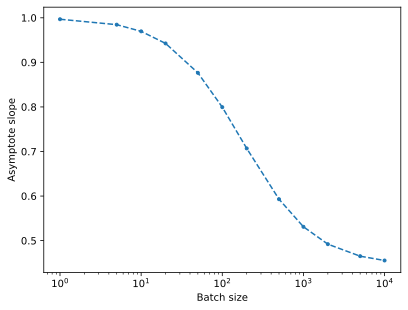

In [16]:
labels = [int(i) for i in labels]
plt.semilogx(labels,a_BP_batchsweep,'.--')
plt.xlabel("Batch size")
plt.ylabel("Asymptote slope")

slope 0.9348109520934665
intercept -4.799313329021185
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


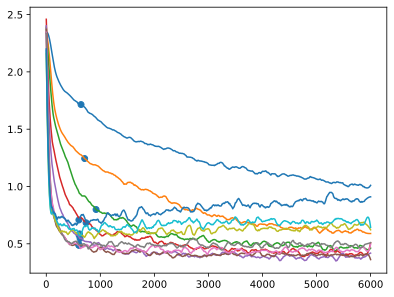

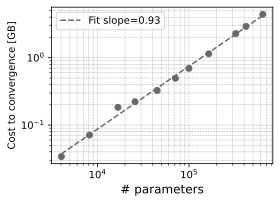

slope 0.7700007394505881
intercept -3.914261172158338
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


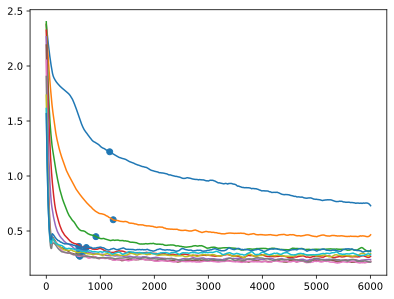

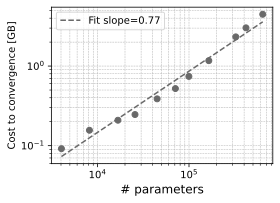

slope 0.7438182628851452
intercept -3.7499913083836143
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


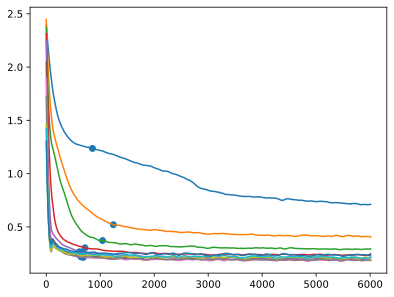

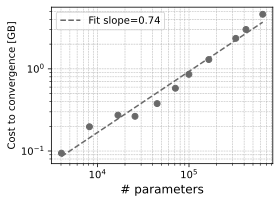

slope 0.6373674977315281
intercept -3.1695215424672023
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


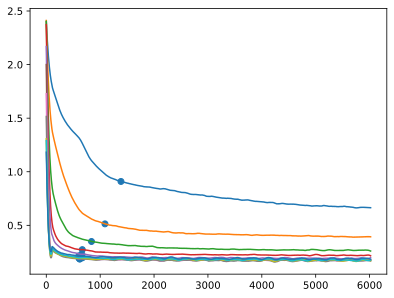

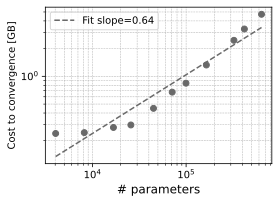

slope 0.4909138663589456
intercept -2.320023730383693
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


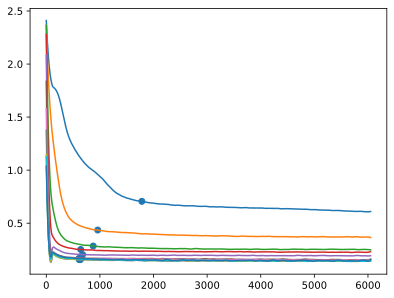

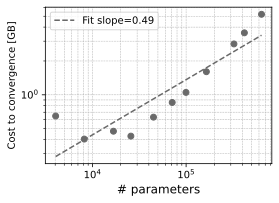

slope 0.41371848549157014
intercept -1.8128065191340188
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


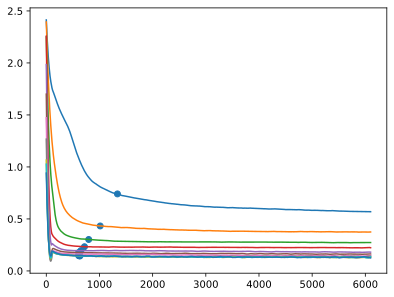

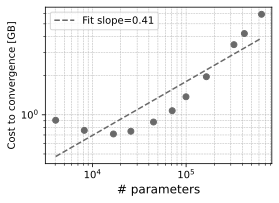

slope 0.3032266612250679
intercept -1.0877013594552412
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


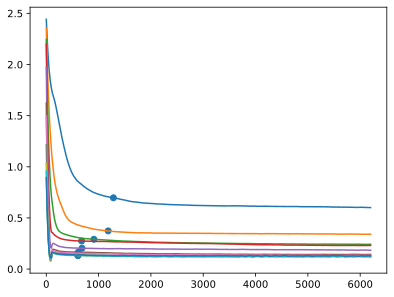

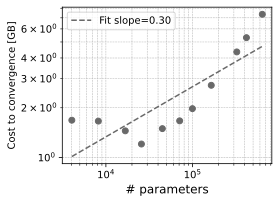

slope 0.20655743528628792
intercept -0.2914741278069339
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


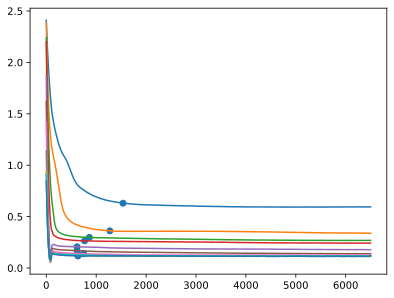

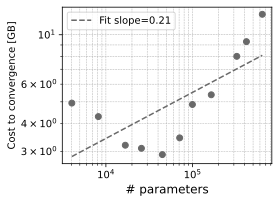

slope 0.1854944665865688
intercept 0.10996017515761405
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


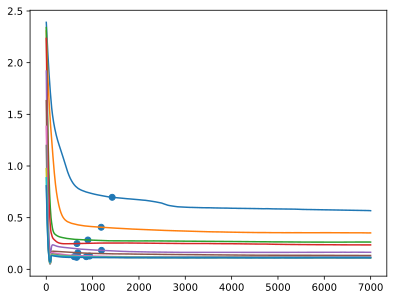

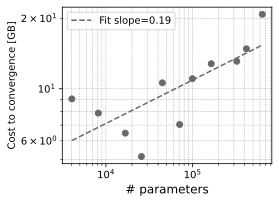

slope 0.17270308385561617
intercept 0.4798810634814763
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


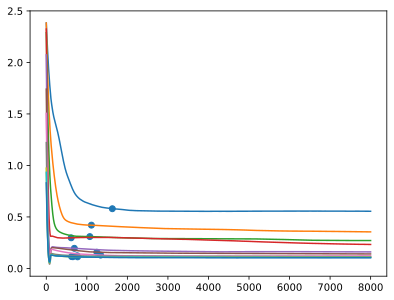

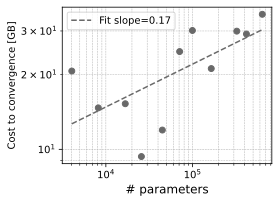

slope 0.1324440972932865
intercept 1.1593774816904685
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


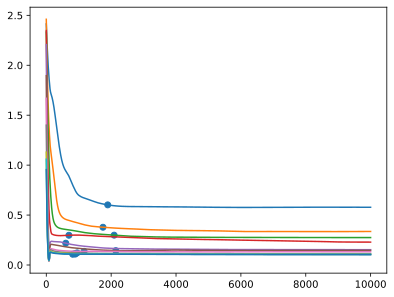

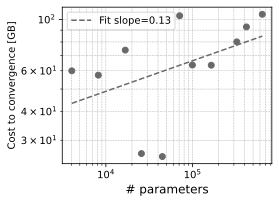

slope 0.2009231168095512
intercept 1.098634160160855
NUms params : [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


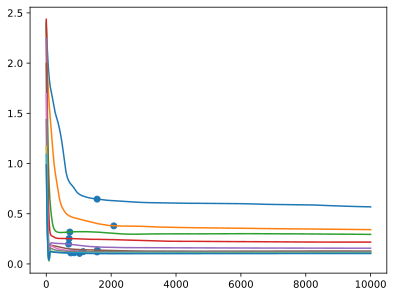

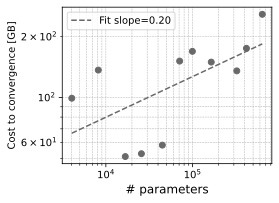

In [17]:
BP_mem_dict = {
    1:   BP_mem_perepoch_1,
    5:   BP_mem_perepoch_5,
    10:  BP_mem_perepoch_10,
    20:  BP_mem_perepoch_20,
    50:  BP_mem_perepoch_50,
    100: BP_mem_perepoch_100,
    200: BP_mem_perepoch_200,
    500: BP_mem_perepoch_500,
    1000: BP_mem_perepoch_1000,
    2000: BP_mem_perepoch_2000,
    5000: BP_mem_perepoch_5000,
    10000: BP_mem_perepoch_10000,
}

results_BP_batch = {}

for batch_size, mem_array in BP_mem_dict.items():

    filename = f'BP_batch_scan/paramscan_batch{batch_size}_PNN_BP_MNIST.pkl'

    with open(filename, 'rb') as f:
        avg_results_BP_batchsweep = pickle.load(f)
    knee_idx_BP_batch,loss_BP_batch,acc_BP_batch = locate_curve_knee(avg_results_BP_batchsweep,N_neurons_vec_BP,idx_start = 300,idx_run=-1,window_len=200,plot_bool=True)
    a, b, N_dim_vec_BP, BP_cost = process_cost_to_conv(avg_results_BP, knee_idx_BP_batch, mem_array)
    results_BP_batch[batch_size] = {
        "a": a,
        "b": b,
        "N_dim": N_dim_vec_BP,
        "cost": BP_cost,
        "knee_idx" : knee_idx_BP_batch,
        "test_loss" : loss_BP_batch,
        "test_acc" : acc_BP_batch
    }

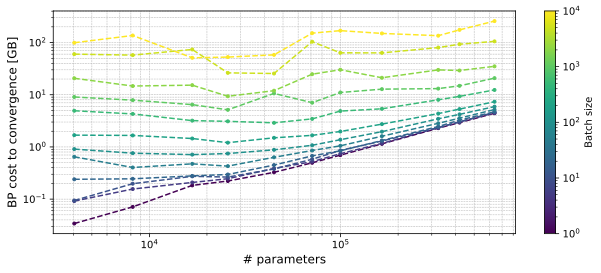

In [18]:

batch_sizes = sorted(results_BP_batch.keys())

plt.figure(figsize=(9, 4))
cmap = plt.cm.viridis
norm = mpl.colors.LogNorm(vmin=min(batch_sizes), vmax=max(batch_sizes))

for bs in batch_sizes:
    N_dim = results_BP_batch[bs]["N_dim"]
    cost  = results_BP_batch[bs]["cost"]
    plt.loglog(N_dim, cost,'--.', color=cmap(norm(bs)), label=f'Batch {bs}')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('BP cost to convergence [GB]', fontsize=12)
plt.grid(True, which="both", ls="--", lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Batch size')

plt.tight_layout()
plt.show()

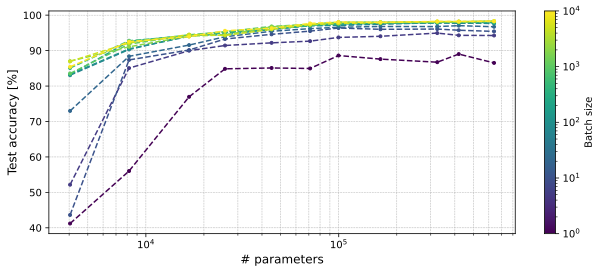

In [19]:

batch_sizes = sorted(results_BP_batch.keys())

plt.figure(figsize=(9, 4))
cmap = plt.cm.viridis
norm = mpl.colors.LogNorm(vmin=min(batch_sizes), vmax=max(batch_sizes))
vec_acc_bs=[]
vec_loss_bs=[]
for bs in batch_sizes:
    N_dim = results_BP_batch[bs]["N_dim"]
    acc_bs  = results_BP_batch[bs]["test_acc"]
    loss_bs  = results_BP_batch[bs]["test_loss"]
    plt.semilogx(N_dim, acc_bs,'--.', color=cmap(norm(bs)), label=f'Batch {bs}')
    vec_acc_bs.append(acc_bs[1])
    vec_loss_bs.append(loss_bs[1])

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Test accuracy [%]', fontsize=12)
plt.grid(True, which="both", ls="--", lw=0.5)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Batch size')

plt.tight_layout()
plt.show()

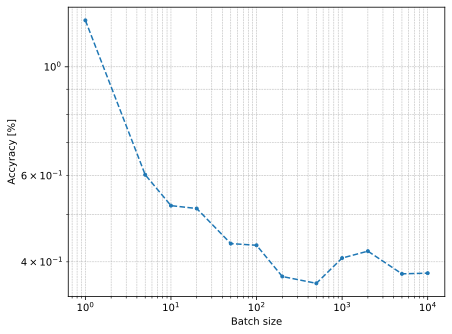

In [20]:
plt.loglog(batch_sizes,vec_loss_bs,'--.')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.ylabel('Accyracy [%]')
plt.xlabel('Batch size')
plt.tight_layout()


BP loss-fit:    slope=-0.417, intercept=1.267
PEPG loss-fit:  slope=-0.727, intercept=2.986
CMA loss-fit:  slope=-0.455, intercept=1.772
SPSA loss-fit:  slope=-0.491, intercept=1.991


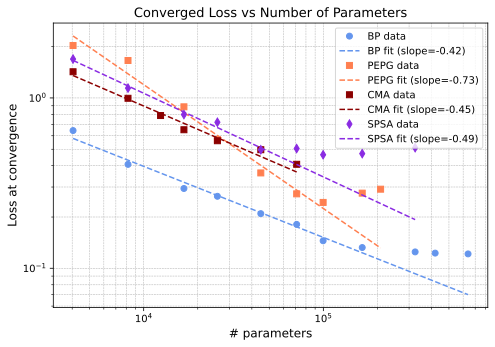

In [21]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP[:-3]), np.log10(loss_BP_conv[:-3]),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec_PEPG[:-2]), np.log10(loss_PEPG_conv[:-2]), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)
a_CMA_l, b_CMA_l = np.polyfit(np.log10(N_dim_vec_CMA[:-1]), np.log10(loss_CMA_conv[:-1]), 1)


print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"CMA loss-fit:  slope={a_CMA_l:.3f}, intercept={b_CMA_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_CMA  = 10**(a_CMA_l * np.log10(N_dim_vec_CMA) + b_CMA_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_dim_vec_BP, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_dim_vec_PEPG, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# CMA — some dark red
plt.loglog(N_dim_vec_CMA, loss_CMA_conv, 's', color='darkred', label='CMA data')
plt.loglog(N_dim_vec_CMA, fit_CMA, '--',  color='darkred', label=f'CMA fit (slope={a_CMA_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_dim_vec_SPSA, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Parameters', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

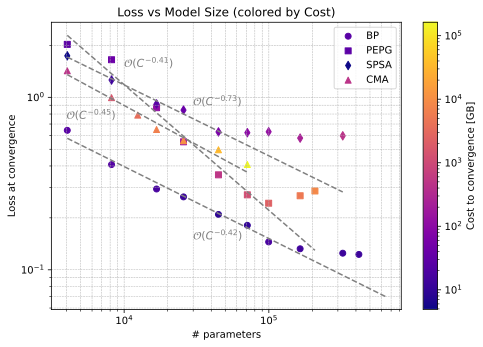

In [46]:
from matplotlib.colors import LogNorm

cmap = plt.cm.plasma

# Colormap now encodes COST
cost_all = np.concatenate([
    np.asarray(BP_cost_to_conv).ravel(),
    np.asarray(PEPG_cost_to_conv).ravel(),
    np.asarray(SPSA_cost_to_conv).ravel(),
    np.asarray(CMA_cost_to_conv).ravel(),
])

norm = LogNorm(vmin=cost_all.min(), vmax=cost_all.max())


# fit
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP[:-3]), np.log10(loss_BP_conv[:-3]),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec_PEPG[:-2]), np.log10(loss_PEPG_conv[:-2]), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)
a_CMA_l, b_CMA_l = np.polyfit(np.log10(N_dim_vec_CMA[:-1]), np.log10(loss_CMA_conv[:-1]), 1)


# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_CMA  = 10**(a_CMA_l * np.log10(N_dim_vec_CMA) + b_CMA_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)


# Figure
fig, ax = plt.subplots(figsize=(7,5))
ax.set_xscale('log')
ax.set_yscale('log')

# Scatter plots
# 
sc_BP = ax.scatter(
    N_dim_vec_BP[:-1], loss_BP_conv[:-1],
    c=BP_cost_to_conv[:-1], cmap=cmap, norm=norm,
    marker='o', label='BP'
)

sc_PEPG = ax.scatter(
    N_dim_vec_PEPG, loss_PEPG_conv,
    c=PEPG_cost_to_conv, cmap=cmap, norm=norm,
    marker='s', label='PEPG'
)

sc_SPSA = ax.scatter(
    N_dim_vec_SPSA, loss_SPSA_conv,
    c=SPSA_cost_to_conv, cmap=cmap, norm=norm,
    marker='d', label='SPSA'
)

sc_CMA = ax.scatter(
    N_dim_vec_CMA, loss_CMA_conv,
    c=CMA_cost_to_conv, cmap=cmap, norm=norm,
    marker='^', label='CMA'
)

# Fit lines 

ax.loglog(
    N_dim_vec_BP,
    fit_BP,
    '--', color='gray'
)

ax.loglog(
    N_dim_vec_PEPG,
    fit_PEPG,
    '--', color='gray'
)

ax.loglog(
    N_dim_vec_SPSA,
    fit_SPSA,
    '--', color='gray'
)

ax.loglog(
    N_dim_vec_CMA,
    fit_CMA,
    '--', color='gray'
)

# Scaling annotations

ax.text(
    3e4, 0.15,
    rf"$\mathcal{{O}}(C^{{{a_BP_l:.2f}}})$",
    color='gray', fontsize=11
)

ax.text(
    3e4, 0.9,
    rf"$\mathcal{{O}}(C^{{{a_PEPG_l:.2f}}})$",
    color='gray', fontsize=11
)

ax.text(
    1e4, 1.5,
    rf"$\mathcal{{O}}(C^{{{a_SPSA_l:.2f}}})$",
    color='gray', fontsize=11
)

ax.text(
    4e3, 0.75,
    rf"$\mathcal{{O}}(C^{{{a_CMA_l:.2f}}})$",
    color='gray', fontsize=11
)

# =========================
# Colorbar (COST)
# =========================
cbar = fig.colorbar(sc_BP, ax=ax)
cbar.set_label('Cost to convergence [GB]')

# =========================
# Labels & style
# =========================
ax.set_xlabel(r'# parameters')
ax.set_ylabel('Loss at convergence')
ax.set_title('Loss vs Model Size (colored by Cost)')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()

BP loss-fit:    slope=-0.417, intercept=1.267
PEPG loss-fit:  slope=-0.728, intercept=2.986
SPSA loss-fit:  slope=-0.411, intercept=1.715
CMA loss-fit:   slope=-0.455, intercept=1.772


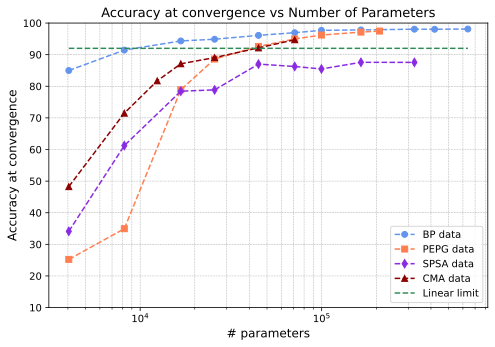

In [47]:
print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")
print(f"CMA loss-fit:   slope={a_CMA_l:.3f}, intercept={b_CMA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP)   + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)
fit_CMA   = 10**(a_CMA_l  * np.log10(N_dim_vec_CMA)  + b_CMA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.semilogx(N_dim_vec_BP, acc_BP_conv, '--o', color='cornflowerblue', label='BP data')

# PEPG — coral
plt.semilogx(N_dim_vec_PEPG, acc_PEPG_conv, '--s', color='coral', label='PEPG data')

# SPSA — blueviolet
plt.semilogx(N_dim_vec_SPSA, acc_SPSA_conv, '--d', color='blueviolet', label='SPSA data')

# CMA — dark red
plt.semilogx(N_dim_vec_CMA, acc_CMA_conv, '--^', color='darkred', label='CMA data')

# linear classifier
plt.semilogx(N_dim_vec_BP, np.ones(len(N_dim_vec_BP))*92, '--',
            color='seagreen', label='Linear limit')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Accuracy at convergence', fontsize=12)
plt.title('Accuracy at convergence vs Number of Parameters', fontsize=13)
plt.ylim([10,100])
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


BP:    slope=-0.116, intercept=1.702
PEPG:  slope=1.500, intercept=-4.179
SPSA:  slope=0.994, intercept=-2.826
CMA:   slope=1.961, intercept=-4.480


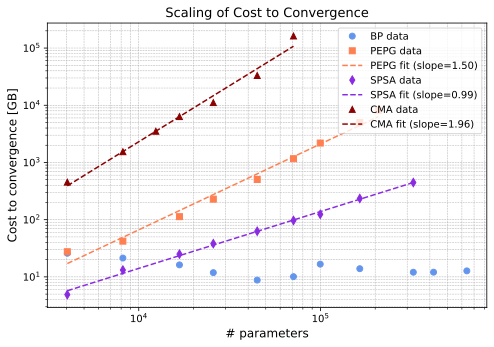

In [48]:
# Fit lines (log-log)
a_BP, b_BP     = np.polyfit(np.log10(N_dim_vec_BP),   np.log10(BP_cost_to_conv),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)
a_CMA, b_CMA   = np.polyfit(np.log10(N_dim_vec_CMA),  np.log10(CMA_cost_to_conv),  1)


# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")
print(f"CMA:   slope={a_CMA:.3f}, intercept={b_CMA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_dim_vec_BP, BP_cost_to_conv, 'o', color='cornflowerblue', label='BP data')

# PEPG — coral
plt.loglog(N_dim_vec_PEPG, PEPG_cost_to_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG,
           10**(a_PEPG*np.log10(N_dim_vec_PEPG) + b_PEPG),
           '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA — blueviolet
plt.loglog(N_dim_vec_SPSA, SPSA_cost_to_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA,
           10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA),
           '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# CMA — dark red
plt.loglog(N_dim_vec_CMA, CMA_cost_to_conv, '^', color='darkred', label='CMA data')
plt.loglog(N_dim_vec_CMA,
           10**(a_CMA*np.log10(N_dim_vec_CMA) + b_CMA),
           '--', color='darkred', label=f'CMA fit (slope={a_CMA:.2f})')

# Labels and style
plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Cost to convergence [GB]', fontsize=12)
plt.title('Scaling of Cost to Convergence', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


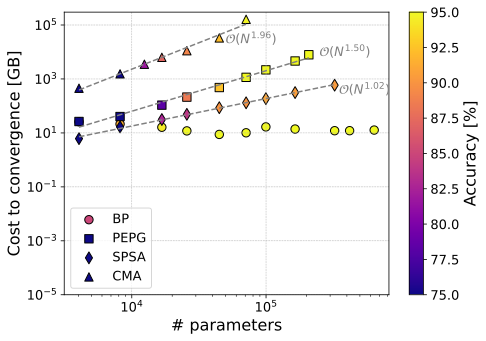

In [62]:
from matplotlib.colors import PowerNorm


mpl.rcParams.update({
    "font.size": 15,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# Fit lines (log-log)
a_BP, b_BP     = np.polyfit(np.log10(N_dim_vec_BP),   np.log10(BP_cost_to_conv),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)
a_CMA, b_CMA   = np.polyfit(np.log10(N_dim_vec_CMA),  np.log10(CMA_cost_to_conv),  1)



cmap = plt.cm.plasma
acc_all = np.concatenate([
    np.asarray(acc_BP_conv).ravel(),
    np.asarray(acc_PEPG_conv).ravel(),
    np.asarray(acc_SPSA_conv).ravel(),
    np.asarray(acc_CMA_conv).ravel(),
])
norm = PowerNorm(gamma = 1, vmin=75, vmax=95)

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xscale('log')
ax.set_yscale('log')

sc_BP = ax.scatter(N_dim_vec_BP, BP_cost_to_conv,
                   c=acc_BP_conv, cmap=cmap, norm=norm,
                   marker='o',s=70, label='BP',edgecolors='black')

sc_PEPG = ax.scatter(N_dim_vec_PEPG, PEPG_cost_to_conv,
                    c=acc_PEPG_conv, cmap=cmap, norm=norm,
                    marker='s',s=70, label='PEPG',edgecolors='black')

ax.loglog(N_dim_vec_PEPG,
           10**(a_PEPG*np.log10(N_dim_vec_PEPG) + b_PEPG),
           '--', color='gray')

ax.text(
    2.5e5, 1e4,
    rf"$\mathcal{{O}}(N^{{{a_PEPG:.2f}}})$",
    color='gray',
    fontsize=13,
    ha='left', va='center'
)


sc_SPSA = ax.scatter(N_dim_vec_SPSA, SPSA_cost_to_conv,
                    c=acc_SPSA_conv, cmap=cmap, norm=norm,
                    marker='d',s=70, label='SPSA',edgecolors='black')
ax.loglog(N_dim_vec_SPSA,
           10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA),
           '--', color='gray')

ax.text(
    3.5e5, 4e2,
    rf"$\mathcal{{O}}(N^{{{a_SPSA:.2f}}})$",
    color='gray',
    fontsize=13,
    ha='left', va='center'
)

ax.loglog(N_dim_vec_CMA,
           10**(a_CMA*np.log10(N_dim_vec_CMA) + b_CMA),
           '--', color='gray')

sc_CMA = ax.scatter(N_dim_vec_CMA, CMA_cost_to_conv,
                    c=acc_CMA_conv, cmap=cmap, norm=norm,
                    marker='^',s=70, label='CMA',edgecolors='black')

ax.text(
    5e4, 3e4,
    rf"$\mathcal{{O}}(N^{{{a_CMA:.2f}}})$",
    color='gray',
    fontsize=13,
    ha='left', va='center'
)

cbar = fig.colorbar(sc_BP, ax=ax)
cbar.set_label('Accuracy [%]')
#cbar.set_ticks([60,70,80,90,100])
ax.set_ylim([1e-5,3e5])
ax.set_yticks([1e-5,1e-3,1e-1,1e1,1e3,1e5])
ax.set_xlabel(r'# parameters')
ax.set_ylabel('Cost to convergence [GB]')
ax.set_title('')
ax.grid(True, which='major', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()
fig.savefig("Plots/Cost_vs_params_acc.svg")


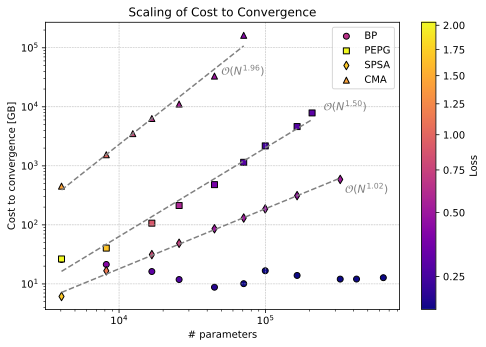

In [23]:

from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm


# Fit lines (log-log)
a_BP, b_BP     = np.polyfit(np.log10(N_dim_vec_BP),   np.log10(BP_cost_to_conv),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)
a_CMA, b_CMA   = np.polyfit(np.log10(N_dim_vec_CMA),  np.log10(CMA_cost_to_conv),  1)

cmap = plt.cm.plasma
loss_all = np.concatenate([
    np.asarray(loss_BP_conv).ravel(),
    np.asarray(loss_PEPG_conv).ravel(),
    np.asarray(loss_SPSA_conv).ravel(),
    np.asarray(loss_CMA_conv).ravel(),
])
norm = PowerNorm(gamma=0.6, vmin=0.2, vmax=loss_all.max())

fig, ax = plt.subplots(figsize=(7,5))
ax.set_xscale('log')
ax.set_yscale('log')

sc_BP = ax.scatter(
    N_dim_vec_BP, BP_cost_to_conv,
    c=loss_BP_conv, cmap=cmap, norm=norm,
    marker='o', label='BP',edgecolors='black'
)

sc_PEPG = ax.scatter(
    N_dim_vec_PEPG, PEPG_cost_to_conv,
    c=loss_PEPG_conv, cmap=cmap, norm=norm,
    marker='s', label='PEPG',edgecolors='black'
)

ax.loglog(
    N_dim_vec_PEPG,
    10**(a_PEPG*np.log10(N_dim_vec_PEPG) + b_PEPG),
    '--', color='gray'
)

ax.text(
    2.5e5, 1e4,
    rf"$\mathcal{{O}}(N^{{{a_PEPG:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)

sc_SPSA = ax.scatter(
    N_dim_vec_SPSA, SPSA_cost_to_conv,
    c=loss_SPSA_conv, cmap=cmap, norm=norm,
    marker='d', label='SPSA',edgecolors='black'
)

ax.loglog(
    N_dim_vec_SPSA,
    10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA),
    '--', color='gray'
)

ax.text(
    3.5e5, 4e2,
    rf"$\mathcal{{O}}(N^{{{a_SPSA:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)

ax.loglog(
    N_dim_vec_CMA,
    10**(a_CMA*np.log10(N_dim_vec_CMA) + b_CMA),
    '--', color='gray'
)

sc_CMA = ax.scatter(
    N_dim_vec_CMA, CMA_cost_to_conv,
    c=loss_CMA_conv, cmap=cmap, norm=norm,
    marker='^', label='CMA',edgecolors='black'
)

ax.text(
    5e4, 4e4,
    rf"$\mathcal{{O}}(N^{{{a_CMA:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)

cbar = fig.colorbar(sc_BP, ax=ax)
cbar.set_label('Loss')

ax.set_xlabel(r'# parameters')
ax.set_ylabel('Cost to convergence [GB]')
ax.set_title('Scaling of Cost to Convergence')
ax.grid(True, which='major', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()
fig.savefig("Plots/Cost_vs_params_loss.svg")



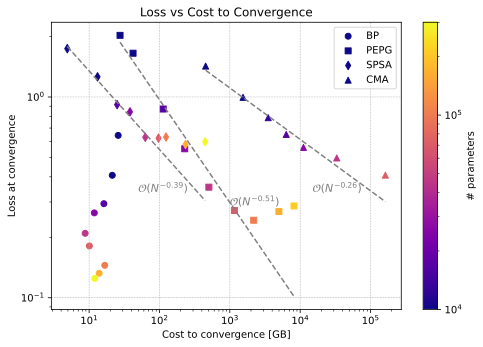

In [51]:

cmap = plt.cm.plasma

N_all = np.concatenate([
    np.asarray(N_dim_vec_BP).ravel(),
    np.asarray(N_dim_vec_PEPG).ravel(),
    np.asarray(N_dim_vec_SPSA).ravel(),
    np.asarray(N_dim_vec_CMA).ravel(),
])

norm = LogNorm(vmin=1e4, vmax=3e5)


# Fit lines (log-log)
a_BP, b_BP     = np.polyfit(np.log10(BP_cost_to_conv[4:]),        np.log10(loss_BP_conv[4:]),        1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv[:-2]),     np.log10(loss_PEPG_conv[:-2]),     1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]),     np.log10(loss_SPSA_conv[:-4]),     1)
a_CMA, b_CMA   = np.polyfit(np.log10(CMA_cost_to_conv[:-1]),      np.log10(loss_CMA_conv[:-1]),      1)

#ocnvert cost to convergence in GB to Joules
DRAM_access_factor = 0.16 #0.16 J / GB using float32 DRAM has an access cost of 20pJ/bit

BP_cost_to_conv_E = DRAM_access_factor * BP_cost_to_conv
PEPG_cost_to_conv_E = DRAM_access_factor * PEPG_cost_to_conv
SPSA_cost_to_conv_E = DRAM_access_factor * SPSA_cost_to_conv
CMA_cost_to_conv_E = DRAM_access_factor * CMA_cost_to_conv

# Figure
fig, ax = plt.subplots(figsize=(7,5))
ax.set_xscale('log')     
ax.set_yscale('log')      

# Scatter plots
sc_BP = ax.scatter(
    BP_cost_to_conv[:-2], loss_BP_conv[:-2],
    c=N_dim_vec_BP[:-2], cmap=cmap, norm=norm,
    marker='o', label='BP'
)

sc_PEPG = ax.scatter(
    PEPG_cost_to_conv, loss_PEPG_conv,
    c=N_dim_vec_PEPG, cmap=cmap, norm=norm,
    marker='s', label='PEPG'
)

ax.loglog(PEPG_cost_to_conv,
           10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG),
           '--', color='gray')

ax.text(
    1000, 0.3,
    rf"$\mathcal{{O}}(N^{{{a_PEPG:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)


sc_SPSA = ax.scatter(
    SPSA_cost_to_conv, loss_SPSA_conv,
    c=N_dim_vec_SPSA, cmap=cmap, norm=norm,
    marker='d', label='SPSA'
)

ax.loglog(SPSA_cost_to_conv,
           10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA),
           '--', color='gray')

ax.text(
    5e1, 0.35,
    rf"$\mathcal{{O}}(N^{{{a_SPSA:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)


sc_CMA = ax.scatter(
    CMA_cost_to_conv, loss_CMA_conv,
    c=N_dim_vec_CMA, cmap=cmap, norm=norm,
    marker='^', label='CMA'
)

ax.loglog(CMA_cost_to_conv,
           10**(a_CMA*np.log10(CMA_cost_to_conv) + b_CMA),
           '--', color='gray')


ax.text(
    1.5e4, 0.35,
    rf"$\mathcal{{O}}(N^{{{a_CMA:.2f}}})$",
    color='gray',
    fontsize=11,
    ha='left', va='center'
)


cbar = fig.colorbar(sc_BP, ax=ax)
cbar.set_label(r'# parameters')

ax.set_xlabel('Cost to convergence [GB]')
ax.set_ylabel('Loss at convergence')
ax.set_title('Loss vs Cost to Convergence')
ax.grid(True, which='major', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()


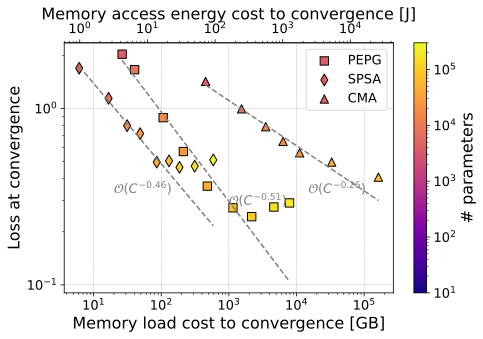

In [63]:


mpl.rcParams.update({
    "font.size": 15,          # base size
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

cmap = plt.cm.plasma

N_all = np.concatenate([
    np.asarray(N_dim_vec_BP).ravel(),
    np.asarray(N_dim_vec_PEPG).ravel(),
    np.asarray(N_dim_vec_SPSA).ravel(),
    np.asarray(N_dim_vec_CMA).ravel(),
])

norm = LogNorm(vmin=1e1, vmax=3e5)

# Fit lines (log-log): loss vs cost
a_BP, b_BP     = np.polyfit(np.log10(BP_cost_to_conv[4:]),    np.log10(loss_BP_conv[4:]),    1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv[:-2]), np.log10(loss_PEPG_conv[:-2]), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)
a_CMA, b_CMA   = np.polyfit(np.log10(CMA_cost_to_conv[:-1]),  np.log10(loss_CMA_conv[:-1]),  1)

# convert cost to convergence in GB to Joules
DRAM_access_factor = 0.16  # J / GB

BP_cost_to_conv_E   = DRAM_access_factor * BP_cost_to_conv
PEPG_cost_to_conv_E = DRAM_access_factor * PEPG_cost_to_conv
SPSA_cost_to_conv_E = DRAM_access_factor * SPSA_cost_to_conv
CMA_cost_to_conv_E  = DRAM_access_factor * CMA_cost_to_conv

# Figure
fig, ax = plt.subplots(figsize=(7,5))
ax.set_xscale('log')
ax.set_yscale('log')

# ---- Secondary x-axis (top): Energy [J]
def cost_to_energy(x_gb):
    return DRAM_access_factor * x_gb

def energy_to_cost(x_j):
    return x_j / DRAM_access_factor

secax = ax.secondary_xaxis('top', functions=(cost_to_energy, energy_to_cost))
secax.set_xscale('log')
secax.set_xlabel('Memory access energy cost to convergence [J]')

# Scatter plots (color = #params)
#sc_BP = ax.scatter(
#    BP_cost_to_conv[:-2], loss_BP_conv[:-2],
#    c=N_dim_vec_BP[:-2], cmap=cmap, norm=norm,
#    marker='o', label='BP',edgecolors='black'
#)

sc_PEPG = ax.scatter(
    PEPG_cost_to_conv, loss_PEPG_conv,
    c=N_dim_vec_PEPG, cmap=cmap, norm=norm,
    marker='s',s=70, label='PEPG',edgecolors='black'
)

ax.loglog(
    PEPG_cost_to_conv,
    10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG),
    '--', color='gray'
)

ax.text(
    1000, 0.3,
    rf"$\mathcal{{O}}(C^{{{a_PEPG:.2f}}})$",
    color='gray', fontsize=13,
    ha='left', va='center'
)

sc_SPSA = ax.scatter(
    SPSA_cost_to_conv, loss_SPSA_conv,
    c=N_dim_vec_SPSA, cmap=cmap, norm=norm,
    marker='d',s=70, label='SPSA',edgecolors='black'
)

ax.loglog(
    SPSA_cost_to_conv,
    10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA),
    '--', color='gray'
)

ax.text(
    2e1, 0.35,
    rf"$\mathcal{{O}}(C^{{{a_SPSA:.2f}}})$",
    color='gray', fontsize=13,
    ha='left', va='center'
)

sc_CMA = ax.scatter(
    CMA_cost_to_conv, loss_CMA_conv,
    c=N_dim_vec_CMA, cmap=cmap, norm=norm,
    marker='^',s=70, label='CMA',edgecolors='black'
)

ax.loglog(
    CMA_cost_to_conv,
    10**(a_CMA*np.log10(CMA_cost_to_conv) + b_CMA),
    '--', color='gray'
)

ax.text(
    1.5e4, 0.35,
    rf"$\mathcal{{O}}(C^{{{a_CMA:.2f}}})$",
    color='gray', fontsize=13,
    ha='left', va='center'
)

# Colorbar (# parameters)
cbar = fig.colorbar(sc_PEPG, ax=ax)
cbar.set_label(r'# parameters')
#cbar.set_ticks([1e1, 1e2, 1e3, 1e4, 1e5])
# Labels & style
#ax.set_xlim([1e-5,1e5])

ax.set_xlabel('Memory load cost to convergence [GB]')
ax.set_ylabel('Loss at convergence')
ax.set_title('')
ax.grid(True, which='major', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()
fig.savefig("Plots/Loss_vs_costpenergy.svg")


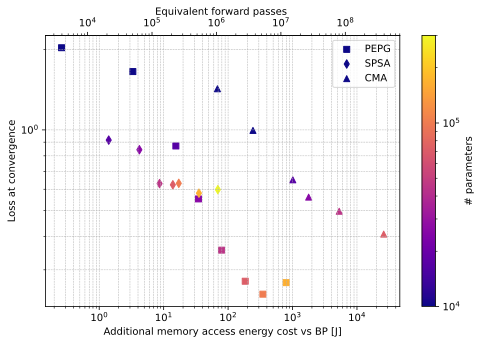

In [53]:

N_dim_vec_BP   = np.array(N_dim_vec_BP)
N_dim_vec_PEPG = np.array(N_dim_vec_PEPG)
N_dim_vec_SPSA = np.array(N_dim_vec_SPSA)
N_dim_vec_CMA  = np.array(N_dim_vec_CMA)

BP_cost_to_conv   = np.array(BP_cost_to_conv)
PEPG_cost_to_conv = np.array(PEPG_cost_to_conv)
SPSA_cost_to_conv = np.array(SPSA_cost_to_conv)
CMA_cost_to_conv  = np.array(CMA_cost_to_conv)

loss_BP_conv   = np.array(loss_BP_conv)
loss_PEPG_conv = np.array(loss_PEPG_conv)
loss_SPSA_conv = np.array(loss_SPSA_conv)
loss_CMA_conv  = np.array(loss_CMA_conv)

# Convert GB cost to Joules
DRAM_access_factor = 0.16  # J / GB

BP_E   = DRAM_access_factor * BP_cost_to_conv
PEPG_E = DRAM_access_factor * PEPG_cost_to_conv
SPSA_E = DRAM_access_factor * SPSA_cost_to_conv
CMA_E  = DRAM_access_factor * CMA_cost_to_conv

#because arrays are differnet sizes and contain slightly differemnt num params
def match_by_value(N_bp, N_algo):
    mask_algo = np.isin(N_algo, N_bp)
    algo_idx = np.where(mask_algo)[0]

    # BP indices (BP vector is sorted)
    bp_idx = np.searchsorted(N_bp, N_algo[algo_idx])
    ok = (bp_idx < len(N_bp)) & (N_bp[bp_idx] == N_algo[algo_idx])

    return bp_idx[ok], algo_idx[ok]

# Compute additional energy vs BP
bp_i_pepg, pepg_i = match_by_value(N_dim_vec_BP, N_dim_vec_PEPG)
bp_i_spsa, spsa_i = match_by_value(N_dim_vec_BP, N_dim_vec_SPSA)
bp_i_cma,  cma_i  = match_by_value(N_dim_vec_BP,  N_dim_vec_CMA)

dE_PEPG = PEPG_E[pepg_i] - BP_E[bp_i_pepg]
dE_SPSA = SPSA_E[spsa_i] - BP_E[bp_i_spsa]
dE_CMA  = CMA_E[cma_i]   - BP_E[bp_i_cma]

loss_PEPG_m = loss_PEPG_conv[pepg_i]
loss_SPSA_m = loss_SPSA_conv[spsa_i]
loss_CMA_m  = loss_CMA_conv[cma_i]

N_PEPG_m = N_dim_vec_PEPG[pepg_i]
N_SPSA_m = N_dim_vec_SPSA[spsa_i]
N_CMA_m  = N_dim_vec_CMA[cma_i]


cmap = plt.cm.plasma
norm = LogNorm(vmin=1e4, vmax=3e5)


fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xscale('log')
ax.set_yscale('log')

sc_PEPG = ax.scatter(
    dE_PEPG, loss_PEPG_m,
    c=N_PEPG_m, cmap=cmap, norm=norm,
    marker='s', label='PEPG'
)

sc_SPSA = ax.scatter(
    dE_SPSA, loss_SPSA_m,
    c=N_SPSA_m, cmap=cmap, norm=norm,
    marker='d', label='SPSA'
)

sc_CMA = ax.scatter(
    dE_CMA, loss_CMA_m,
    c=N_CMA_m, cmap=cmap, norm=norm,
    marker='^', label='CMA'
)

# compute how many inferences that correpsondes to 
E_ref = 5e-3      # J / inference for reference model (e.g., MobileNetV2 on Edge TPU)
N_ref = 3.4e6     # reference parameter count


N_typ = np.median(N_all)          #  representative model size
E_inf = E_ref * (N_typ / N_ref)   # typical inference energy 

def energy_to_fw(E_j):
    return E_j / E_inf

def fw_to_energy(N_fw):
    return N_fw * E_inf

secax = ax.secondary_xaxis('top', functions=(energy_to_fw, fw_to_energy))
secax.set_xscale('log')
secax.set_xlabel(
    rf'Equivalent forward passes ')
    #rf'($E_\mathrm{{inf}}\approx{E_inf*1e3:.2f}$ mJ, $N_{{typ}}={N_typ:.2g}$)'
#)

# Colorbar (shared scale = #params)
cbar = fig.colorbar(sc_PEPG, ax=ax)
cbar.set_label(r'# parameters')

# Labels & style
ax.set_xlabel('Additional memory access energy cost vs BP [J]')
ax.set_ylabel('Loss at convergence')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend()

fig.tight_layout()
plt.show()


In [34]:
N_dim_vec_CMA

array([ 4045,  8180, 12415, 16750, 25720, 44860])

In [35]:
N_dim_vec_BP

array([  4045,   8180,  16750,  25720,  44860,  71035,  99710, 164560,
       324260, 419110, 638810])

In [36]:
N_dim_vec_SPSA[np.array(N_dim_vec_BP[:m]) == np.array(N_dim_vec_SPSA[:m])]

NameError: name 'm' is not defined

BP:    slope=-0.901, intercept=0.214
PEPG:  slope=-0.582, intercept=1.188
SPSA:  slope=-0.392, intercept=0.522
CMA:   slope=-0.254, intercept=0.825


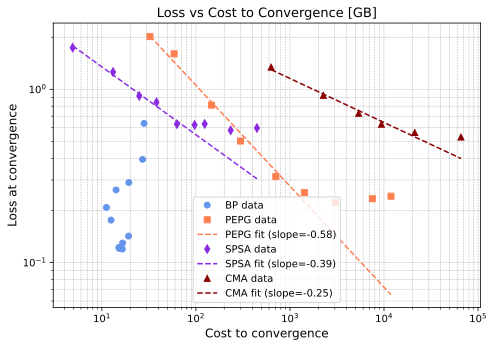

In [ ]:
# Fit lines (log-log)
a_BP, b_BP     = np.polyfit(np.log10(BP_cost_to_conv[4:]),        np.log10(loss_BP_conv[4:]),        1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv[:-3]),     np.log10(loss_PEPG_conv[:-3]),     1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]),     np.log10(loss_SPSA_conv[:-4]),     1)
a_CMA, b_CMA   = np.polyfit(np.log10(CMA_cost_to_conv[:-1]),      np.log10(loss_CMA_conv[:-1]),      1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")
print(f"CMA:   slope={a_CMA:.3f}, intercept={b_CMA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(BP_cost_to_conv, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')

# PEPG — coral
plt.loglog(PEPG_cost_to_conv, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(PEPG_cost_to_conv,
           10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG),
           '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA — blueviolet
plt.loglog(SPSA_cost_to_conv, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(SPSA_cost_to_conv,
           10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA),
           '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# CMA — dark red
plt.loglog(CMA_cost_to_conv, loss_CMA_conv, '^', color='darkred', label='CMA data')
plt.loglog(CMA_cost_to_conv,
           10**(a_CMA*np.log10(CMA_cost_to_conv) + b_CMA),
           '--', color='darkred', label=f'CMA fit (slope={a_CMA:.2f})')

# Labels and styling
plt.xlabel('Cost to convergence', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Loss vs Cost to Convergence [GB]', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


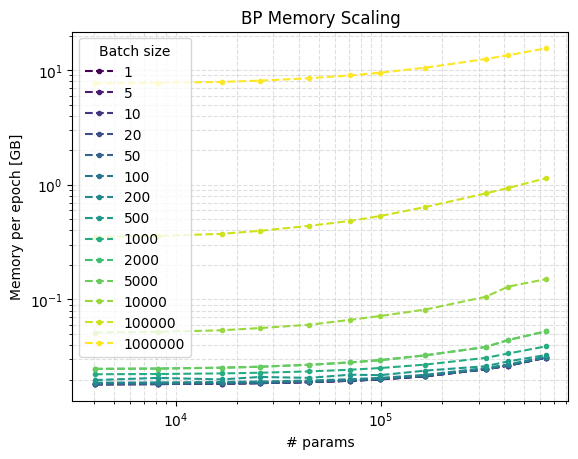

In [ ]:
#with measured load from CUDA torch instead of theory

BP_mem_perepoch_1 = np.array([18.19, 18.269, 18.443, 18.622, 19.001, 19.521, 20.097, 21.395, 24.587, 26.489, 31.049])/1000 
BP_mem_perepoch_5 = np.array([18.202, 18.281, 18.456, 18.635, 19.014, 19.533, 20.109, 21.407, 24.6, 26.502, 31.061])/1000
BP_mem_perepoch_10 = np.array([18.218, 18.297, 18.471, 18.651, 19.03, 19.549, 20.125, 21.423, 24.615, 26.518, 31.077])/1000 
BP_mem_perepoch_20 = np.array([18.249, 18.329, 18.503, 18.682, 19.061, 19.58, 20.156, 21.454, 24.647, 26.549, 31.108])/1000 
BP_mem_perepoch_50 = np.array([18.343, 18.423, 18.597, 18.776, 19.155, 19.675, 20.251, 21.549, 24.741, 26.643, 31.202])/1000 
BP_mem_perepoch_100 = np.array([18.501, 18.58, 18.754, 18.933, 19.312, 19.832, 20.408, 21.706, 24.898, 26.8, 31.359])/1000
BP_mem_perepoch_200 = np.array([18.815, 18.894, 19.068, 19.248, 19.626, 20.146, 20.722, 22.02, 25.212, 27.114, 31.674])/1000 

BP_mem_perepoch_500 = np.array([19.812, 20.686, 20.076, 21.079, 20.711, 22.068, 21.87, 23.945, 26.156, 28.853, 32.762])/1000 
BP_mem_perepoch_1000 = np.array([22.27, 22.378, 22.643, 22.951, 23.578, 24.39, 25.239, 27.018, 30.939, 33.817, 38.973])/1000
BP_mem_perepoch_2000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000

BP_mem_perepoch_5000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000 
BP_mem_perepoch_10000 = np.array([51.487, 52.135, 53.84, 56.279, 60.176, 66.421, 71.805, 81.615, 105.478, 129.487, 150.402])/1000 
BP_mem_perepoch_100000 = np.array([351.973, 358.021, 373.674, 396.697, 438.867, 484.323, 534.669, 639.537, 840.686, 938.513, 1141.897])/1000 
BP_mem_perepoch_1000000 = np.array([7681.618, 7741.665, 7901.772, 8101.879, 8502.107, 9002.421, 9504.99, 10503.547, 12507.174, 13506.61, 15511.27])/1000 

#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
    BP_mem_perepoch_100000,
    BP_mem_perepoch_1000000
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000","100000","1000000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()


Text(0, 0.5, 'Asymptote slope')

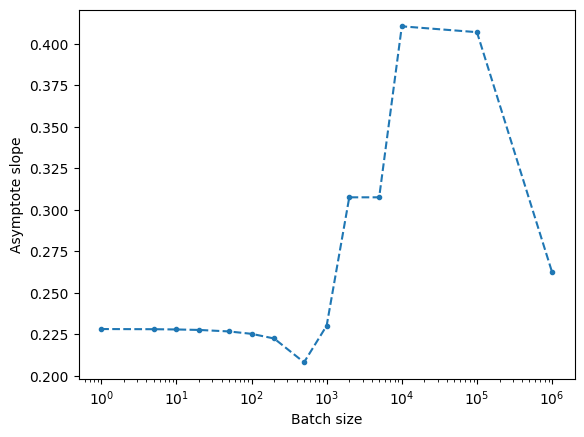

In [ ]:
labels = [int(i) for i in labels]
plt.semilogx(labels,a_BP_batchsweep,'.--')
plt.xlabel("Batch size")
plt.ylabel("Asymptote slope")